# Imports & helpers

In [4]:

import os
import numpy as np
import pandas as pd
import joblib
import warnings
warnings.filterwarnings("ignore")
from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from imblearn.over_sampling import SMOTE

import shap

def make_ohe(**kwargs):
    try:

        return OneHotEncoder(**(dict(kwargs, **{"sparse_output": False})))
    except TypeError:

        return OneHotEncoder(**(dict(kwargs, **{"sparse": False})))


# Load data

In [5]:

from google.colab import files
uploaded = files.upload()
df = pd.read_csv(CSV_PATH)
print("Loaded shape:", df.shape)
print("Columns:", len(df.columns))
display(df.head())


Saving thyroidcancerupstaging_blindeddata_final.csv to thyroidcancerupstaging_blindeddata_final (1).csv
Loaded shape: (5351, 59)
Columns: 59


,TumorID.blind,patientID.blind,ReportingHospitalID,PrimarySequence,ClassCaseDesc,AnalyticYn,DateFirstContact.x,DateDx.x,AgeAtDx.x,PrimarySiteCode,...,AgeAtDx.y,LastContactDate,VitalStatus,DeathDate,index,death,recurred,dx.to.surg.days,firstcontact.to.surg.days,surg.to.radtx.days
0,1,1,Hospital.A,Malignant primary #2,14 - Initial diagnosis at the reporting facili...,1,2017,2017,62,C73.9,...,62,2020.0,True,NaN,1,alive,no recurrence,0.0,0.0,NaN
1,2,2,Hospital.A,Malignant primary #2,14 - Initial diagnosis at the reporting facili...,1,2015,2015,67,C73.9,...,67,2018.0,True,NaN,2,alive,no recurrence,0.0,0.0,NaN
2,3,3,Hospital.A,Malignant primary #2,21 - Initial diagnosis elsewhere AND PART of t...,1,2016,2015,70,C73.9,...,70,2020.0,True,NaN,3,alive,no recurrence,22.0,-48.0,48.0
3,4,4,Hospital.A,Malignant primary #2,21 - Initial diagnosis elsewhere AND PART of t...,1,2015,2015,68,C73.9,...,68,2020.0,True,NaN,4,alive,recurrence,48.0,0.0,64.0
4,5,5,Hospital.A,Malignant primary #2,14 - Initial diagnosis at the reporting facili...,1,2015,2015,57,C73.9,...,57,2020.0,True,NaN,5,alive,no recurrence,0.0,0.0,NaN


#  Detect recurrence target column

In [6]:

candidate_targets = ["recurred", "Recurred", "recurrence", "Recurrence", "FirstRecurrenceType", "FirstRecurrenceDate", "RecurrenceStatus", "recurrence_status"]
found = None
for c in candidate_targets:
    if c in df.columns:
        found = c
        break

if found is None:
    print("Tried these candidate target names:", candidate_targets)
    raise KeyError("No recurrence column found. Rename your recurrence column to one of the candidate names or tell me the exact name.")

print("Using target column:", found)
TARGET = found


print(df[TARGET].dtype)
print(df[TARGET].value_counts(dropna=False).head(20))


Using target column: recurred
object
recurred
no recurrence    5211
recurrence        140
Name: count, dtype: int64


# Convert target to binary if appears categorical/text

In [7]:

y_raw = df[TARGET].copy()

if pd.api.types.is_numeric_dtype(y_raw):
    uniq = y_raw.dropna().unique()
    if len(uniq) <= 2:
        df[TARGET] = y_raw.fillna(0).astype(int)
    else:

        df[TARGET] = (~y_raw.isna()).astype(int)
else:
    def map_rec(v):
        if pd.isna(v):
            return 0
        s = str(v).strip().lower()
        if s in ("1","yes","y","true","recurrence","recurred","local","distant"):
            return 1
        if any(ch.isdigit() for ch in s) and ("-" in s or "/" in s):
            return 1
        return 0
    df[TARGET] = y_raw.map(map_rec).fillna(0).astype(int)

print("Mapped target distribution:")
print(df[TARGET].value_counts())


Mapped target distribution:
recurred
0    5211
1     140
Name: count, dtype: int64


# Drop columns that leak or are IDs

In [8]:

drop_patterns = [
    "Path", "MstDefSurgeryDate", "MstDefRtDate", "MstDefChemoDate", "MstDefHormoneDate",
    "MstDefImmunoDate", "FirstRecurrenceDate", "FirstRecurrenceType", "DeathDate", "LastContactDate",
    "Death", "VitalStatus", "recurred", ".y", "TumorID", "patientID", "ReportingHospitalID", "index"
]
cols_to_drop = []
for col in df.columns:
    low = col.lower()
    if any(pat.lower() in low for pat in drop_patterns):
        cols_to_drop.append(col)


cols_to_drop = [c for c in cols_to_drop if c != TARGET]
print("Dropping columns (count):", len(cols_to_drop))
print(cols_to_drop[:50])
df = df.drop(columns=cols_to_drop, errors='ignore')
print("Shape after drop:", df.shape)


Dropping columns (count): 23
['TumorID.blind', 'patientID.blind', 'ReportingHospitalID', 'PathT', 'PathN', 'PathM', 'PathStage', 'MstDefSurgeryDate', 'MstDefRtDate', 'MstDefChemoDate', 'MstDefHormoneDate', 'MstDefImmunoDate', 'FirstRecurrenceDate', 'FirstRecurrenceType', 'PrimarySiteSubcategory.y', 'DateFirstContact.y', 'DateDx.y', 'AgeAtDx.y', 'LastContactDate', 'VitalStatus', 'DeathDate', 'index', 'death']
Shape after drop: (5351, 36)


# Automatically select safe features (pre-op)

In [9]:

keep_keywords = ["age", "sex", "race", "clin", "histology", "laterality", "grade", "lvinvasion", "primarysite", ".x", "dx.to.surg", "surg.to", "firstcontact"]
features = []
for col in df.columns:
    if col == TARGET:
        continue
    low = col.lower()
    if any(k in low for k in keep_keywords):
        features.append(col)

if len(features) == 0:
    features = [c for c in df.columns if c != TARGET]

print("Auto-selected features (count):", len(features))
print(features[:80])
X = df[features].copy()
y = df[TARGET].copy()
print("X shape, y shape:", X.shape, y.shape)


Auto-selected features (count): 22
['DateFirstContact.x', 'DateDx.x', 'AgeAtDx.x', 'PrimarySiteCode', 'PrimarySiteDesc', 'PrimarySiteCategory', 'PrimarySiteSubcategory.x', 'HistologyCode', 'HistologyDesc', 'Laterality', 'Grade', 'LvInvasion', 'ClinT', 'ClinN', 'ClinM', 'ClinStage', 'SummaryStage', 'Sex', 'Race', 'dx.to.surg.days', 'firstcontact.to.surg.days', 'surg.to.radtx.days']
X shape, y shape: (5351, 22) (5351,)


# Check dtypes and missingness

In [10]:
print(X.dtypes.value_counts())
missing = X.isnull().sum().sort_values(ascending=False)
display(missing[missing>0].head(40))


object     17
float64     3
int64       2
Name: count, dtype: int64


,0
surg.to.radtx.days,3257
ClinM,665
ClinT,438
ClinN,399
dx.to.surg.days,162
firstcontact.to.surg.days,162
ClinStage,20
LvInvasion,5


# Preprocessor (impute numeric median, categorical most frequent, encode)

In [11]:
num_cols = X.select_dtypes(include=['int64','float64','int','float']).columns.tolist()
cat_cols = X.select_dtypes(include=['object','category','bool']).columns.tolist()

print("Numeric cols:", num_cols)
print("Categorical cols:", cat_cols)

num_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
cat_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', make_ohe(handle_unknown='ignore', drop='first'))
])

preprocessor = ColumnTransformer([
    ('num', num_transformer, num_cols),
    ('cat', cat_transformer, cat_cols)
], remainder='drop')


Numeric cols: ['DateFirstContact.x', 'DateDx.x', 'dx.to.surg.days', 'firstcontact.to.surg.days', 'surg.to.radtx.days']
Categorical cols: ['AgeAtDx.x', 'PrimarySiteCode', 'PrimarySiteDesc', 'PrimarySiteCategory', 'PrimarySiteSubcategory.x', 'HistologyCode', 'HistologyDesc', 'Laterality', 'Grade', 'LvInvasion', 'ClinT', 'ClinN', 'ClinM', 'ClinStage', 'SummaryStage', 'Sex', 'Race']


# Split (80/20)

In [12]:

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)
print("Train/test shapes:", X_train_raw.shape, X_test_raw.shape)
print("Train target distribution:", y_train.value_counts(normalize=True))
print("Test target distribution:", y_test.value_counts(normalize=True))


Train/test shapes: (4280, 22) (1071, 22)
Train target distribution: recurred
0    0.973832
1    0.026168
Name: proportion, dtype: float64
Test target distribution: recurred
0    0.973856
1    0.026144
Name: proportion, dtype: float64


# Fit preprocessor on X_train and transform both train/test

In [13]:

X_train_p = preprocessor.fit_transform(X_train_raw)
X_test_p = preprocessor.transform(X_test_raw)

ohe = preprocessor.named_transformers_['cat'].named_steps['onehot']
try:
    cat_feature_names = list(ohe.get_feature_names_out(cat_cols))
except Exception:

    cat_feature_names = []
    for i, col in enumerate(cat_cols):
        cats = ohe.categories_[i]
        cat_feature_names += [f"{col}_{v}" for v in cats[1:]]  # drop-first applied

num_feature_names = num_cols
feature_names = list(num_feature_names) + list(cat_feature_names)

print("Preprocessed shapes:", X_train_p.shape, X_test_p.shape)
print("Num features:", len(feature_names))


Preprocessed shapes: (4280, 190) (1071, 190)
Num features: 190


# Ensure finite values

In [14]:

import numpy as np
from sklearn.impute import SimpleImputer

X_train_p = pd.DataFrame(X_train_p, columns=feature_names)
X_test_p = pd.DataFrame(X_test_p, columns=feature_names)


X_train_p.replace([np.inf, -np.inf], np.nan, inplace=True)
X_test_p.replace([np.inf, -np.inf], np.nan, inplace=True)

if X_train_p.isnull().sum().sum() > 0:
    imp = SimpleImputer(strategy='median')
    X_train_p = pd.DataFrame(imp.fit_transform(X_train_p), columns=feature_names)
    X_test_p = pd.DataFrame(imp.transform(X_test_p), columns=feature_names)

print("After cleaning — NaNs train/test:", X_train_p.isnull().sum().sum(), X_test_p.isnull().sum().sum())


After cleaning — NaNs train/test: 0 0


# SMOTE on training set

In [15]:

sm = SMOTE(random_state=42)
X_train_bal, y_train_bal = sm.fit_resample(X_train_p, y_train)
print("Balanced train shape:", X_train_bal.shape, y_train_bal.shape)
print("Balanced class distribution:", np.bincount(y_train_bal))


Balanced train shape: (8336, 190) (8336,)
Balanced class distribution: [4168 4168]


# Quick baseline models DT

In [16]:
from sklearn.tree import DecisionTreeClassifier

dt_improved = DecisionTreeClassifier(
    criterion='gini',
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight='balanced',
    random_state=42
)

dt_improved.fit(X_train_bal, y_train_bal)

dt_pred_test = dt_improved.predict(X_test_p)
print("DT Test Accuracy:", accuracy_score(y_test, dt_pred_test))
print(classification_report(y_test, dt_pred_test))




DT Test Accuracy: 0.9477124183006536
              precision    recall  f1-score   support

           0       0.98      0.96      0.97      1043
           1       0.20      0.32      0.24        28

    accuracy                           0.95      1071
   macro avg       0.59      0.64      0.61      1071
weighted avg       0.96      0.95      0.95      1071



# Decision Tree RandomizedSearchCV DT

In [17]:
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import RandomizedSearchCV

dt = DecisionTreeClassifier(random_state=42)

random_grid_dt = {
    "criterion": ["gini", "entropy"],
    "max_depth": [5, 10, 20, 30, 40, None],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 4, 6],
    "max_features": ["sqrt", "log2", None]
}

dt_randomcv = RandomizedSearchCV(
    estimator=dt,
    param_distributions=random_grid_dt,
    n_iter=30,
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1,
    error_score=np.nan
)

dt_randomcv.fit(X_train_bal, y_train_bal)
print("DT Randomized best params:", dt_randomcv.best_params_)


Fitting 3 folds for each of 30 candidates, totalling 90 fits
DT Randomized best params: {'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': None, 'max_depth': 30, 'criterion': 'gini'}


# Decision Tree with GridSearchCV around best params DT

In [18]:
best_dt = dt_randomcv.best_params_

param_grid_dt = {
    'criterion': [best_dt['criterion']],
    'max_depth': [best_dt['max_depth']],
    'max_features': [best_dt['max_features']],
    'min_samples_leaf': [
        max(1, best_dt['min_samples_leaf'] - 1),
        best_dt['min_samples_leaf'],
        best_dt['min_samples_leaf'] + 1
    ],
    'min_samples_split': [
        max(2, best_dt['min_samples_split'] - 1),
        best_dt['min_samples_split'],
        best_dt['min_samples_split'] + 1
    ]
}

from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)

grid_search_dt = GridSearchCV(
    estimator=dt,
    param_grid=param_grid_dt,
    cv=5,
    n_jobs=-1,
    verbose=2,
    error_score=np.nan
)

grid_search_dt.fit(X_train_bal, y_train_bal)

best_dt_model = grid_search_dt.best_estimator_
print("DT Grid best params:", grid_search_dt.best_params_)


Fitting 5 folds for each of 9 candidates, totalling 45 fits
DT Grid best params: {'criterion': 'gini', 'max_depth': 30, 'max_features': None, 'min_samples_leaf': 2, 'min_samples_split': 2}


# Evaluate best Decision Tree

In [19]:
y_train_pred_dt = best_dt_model.predict(X_train_bal)
y_test_pred_dt = best_dt_model.predict(X_test_p)

print("DT Train Accuracy:", accuracy_score(y_train_bal, y_train_pred_dt))
print("DT Test Accuracy :", accuracy_score(y_test, y_test_pred_dt))
print("Confusion Matrix (test):\n", confusion_matrix(y_test, y_test_pred_dt))
print("Classification Report (test):\n", classification_report(y_test, y_test_pred_dt))


DT Train Accuracy: 0.9928023032629558
DT Test Accuracy : 0.9607843137254902
Confusion Matrix (test):
 [[1025   18]
 [  24    4]]
Classification Report (test):
               precision    recall  f1-score   support

           0       0.98      0.98      0.98      1043
           1       0.18      0.14      0.16        28

    accuracy                           0.96      1071
   macro avg       0.58      0.56      0.57      1071
weighted avg       0.96      0.96      0.96      1071



# Logistic Regression Base

In [20]:
from sklearn.linear_model import LogisticRegression
log = LogisticRegression(max_iter=2000)
log.fit(X_train_bal, y_train_bal)
log_pred_test = log.predict(X_test_p)
print("LogReg Test Accuracy:", accuracy_score(y_test, log_pred_test))
print(classification_report(y_test, log_pred_test))

LogReg Test Accuracy: 0.8225957049486461
              precision    recall  f1-score   support

           0       0.98      0.83      0.90      1043
           1       0.06      0.39      0.10        28

    accuracy                           0.82      1071
   macro avg       0.52      0.61      0.50      1071
weighted avg       0.96      0.82      0.88      1071



# Logistic Regression with RandomizedSearchCV LR

In [21]:
import numpy as np
from sklearn.model_selection import RandomizedSearchCV
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(random_state=42, max_iter=5000)

random_grid_lr = {
    "penalty": ["l1", "l2", "elasticnet", None],
    "C": [0.001, 0.01, 0.1, 1, 10, 100],
    "solver": ["lbfgs", "liblinear", "saga", "newton-cg"],
    "l1_ratio": [0.0, 0.25, 0.5, 0.75, 1.0]
}

lr_randomcv = RandomizedSearchCV(
    estimator=lr,
    param_distributions=random_grid_lr,
    n_iter=30,
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1,
    error_score=np.nan
)

lr_randomcv.fit(X_train_bal, y_train_bal)
print("LR Randomized best params:", lr_randomcv.best_params_)


Fitting 3 folds for each of 30 candidates, totalling 90 fits
LR Randomized best params: {'solver': 'lbfgs', 'penalty': None, 'l1_ratio': 0.0, 'C': 0.1}


# Logistic Regression with GridSearchCV around best params

In [22]:
best_lr = lr_randomcv.best_params_

param_grid_lr = {
    'penalty': [best_lr['penalty']],
    'C': [
        max(0.0001, best_lr['C'] / 10),
        best_lr['C'],
        best_lr['C'] * 10
    ],
    'solver': [best_lr['solver']],
    'l1_ratio': (
        [max(0.0, best_lr.get('l1_ratio', 0) - 0.1),
         best_lr.get('l1_ratio', 0),
         min(1.0, best_lr.get('l1_ratio', 0) + 0.1)]
        if best_lr['penalty'] == "elasticnet" else [None]
    )
}

from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(random_state=42, max_iter=5000)
grid_search_lr = GridSearchCV(
    estimator=lr,
    param_grid=param_grid_lr,
    cv=5,
    n_jobs=-1,
    verbose=2,
    error_score=np.nan
)

grid_search_lr.fit(X_train_bal, y_train_bal)

best_lr_model = grid_search_lr.best_estimator_
print("LR Grid best params:", grid_search_lr.best_params_)


Fitting 5 folds for each of 3 candidates, totalling 15 fits
LR Grid best params: {'C': 0.01, 'l1_ratio': None, 'penalty': None, 'solver': 'lbfgs'}


# Evaluate best Logistic Regression

In [23]:

y_train_pred_lr = best_lr_model.predict(X_train_bal)
y_test_pred_lr = best_lr_model.predict(X_test_p)

print("LR Train Accuracy:", accuracy_score(y_train_bal, y_train_pred_lr))
print("LR Test Accuracy :", accuracy_score(y_test, y_test_pred_lr))
print("Confusion Matrix (test):\n", confusion_matrix(y_test, y_test_pred_lr))
print("Classification Report (test):\n", classification_report(y_test, y_test_pred_lr))


LR Train Accuracy: 0.8652831094049904
LR Test Accuracy : 0.8225957049486461
Confusion Matrix (test):
 [[874 169]
 [ 21   7]]
Classification Report (test):
               precision    recall  f1-score   support

           0       0.98      0.84      0.90      1043
           1       0.04      0.25      0.07        28

    accuracy                           0.82      1071
   macro avg       0.51      0.54      0.49      1071
weighted avg       0.95      0.82      0.88      1071



# RandomForest base

In [24]:

rf_base = RandomForestClassifier(random_state=42)
rf_base.fit(X_train_bal, y_train_bal)
rf_pred_test = rf_base.predict(X_test_p)
print("RF (base) Test Accuracy:", accuracy_score(y_test, rf_pred_test))
print(classification_report(y_test, rf_pred_test))

RF (base) Test Accuracy: 0.9757236227824463
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1043
           1       1.00      0.07      0.13        28

    accuracy                           0.98      1071
   macro avg       0.99      0.54      0.56      1071
weighted avg       0.98      0.98      0.97      1071



# RandomizedSearchCV for RandomForest

In [25]:
import numpy as np
from sklearn.model_selection import RandomizedSearchCV

rf = RandomForestClassifier(random_state=42)
random_grid = {
    "n_estimators": [100,200,300,400,500],
    "max_depth": [5,10,20,30, None],
    "max_features": ["sqrt", "log2"],
    "min_samples_split": [2,5,10],
    "min_samples_leaf": [1,2,4],
    "criterion": ["gini","entropy"]
}

rf_randomcv = RandomizedSearchCV(
    estimator=rf,
    param_distributions=random_grid,
    n_iter=30,
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1,
    error_score=np.nan
)

rf_randomcv.fit(X_train_bal, y_train_bal)
print("RF Randomized best params:", rf_randomcv.best_params_)


Fitting 3 folds for each of 30 candidates, totalling 90 fits
RF Randomized best params: {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': None, 'criterion': 'entropy'}


# RandomForest with GridSearchCV around best params

In [26]:
best = rf_randomcv.best_params_

param_grid = {
    'criterion': [best['criterion']],
    'max_depth': [best['max_depth']],
    'max_features': [best['max_features']],
    'min_samples_leaf': [max(1, best['min_samples_leaf'] - 1), best['min_samples_leaf'], best['min_samples_leaf'] + 1],
    'min_samples_split': [max(2, best['min_samples_split'] - 1), best['min_samples_split'], best['min_samples_split'] + 1],
    'n_estimators': [max(10, best['n_estimators'] - 100), best['n_estimators'], best['n_estimators'] + 100]
}

from sklearn.model_selection import GridSearchCV
rf = RandomForestClassifier(random_state=42)

grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5, n_jobs=-1, verbose=2, error_score=np.nan)
grid_search.fit(X_train_bal, y_train_bal)

best_rf = grid_search.best_estimator_
print("RF Grid best params:", grid_search.best_params_)


Fitting 5 folds for each of 27 candidates, totalling 135 fits
RF Grid best params: {'criterion': 'entropy', 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}


# Evaluate best RandomForest

In [27]:
y_train_pred_rf = best_rf.predict(X_train_bal)
y_test_pred_rf = best_rf.predict(X_test_p)

print("RF Train Accuracy:", accuracy_score(y_train_bal, y_train_pred_rf))
print("RF Test Accuracy :", accuracy_score(y_test, y_test_pred_rf))
print("Confusion Matrix (test):\n", confusion_matrix(y_test, y_test_pred_rf))
print("Classification Report (test):\n", classification_report(y_test, y_test_pred_rf))


RF Train Accuracy: 0.9998800383877159
RF Test Accuracy : 0.9747899159663865
Confusion Matrix (test):
 [[1043    0]
 [  27    1]]
Classification Report (test):
               precision    recall  f1-score   support

           0       0.97      1.00      0.99      1043
           1       1.00      0.04      0.07        28

    accuracy                           0.97      1071
   macro avg       0.99      0.52      0.53      1071
weighted avg       0.98      0.97      0.96      1071



# SVM RandomizedSearchCV

In [28]:
from sklearn.svm import SVC
svm_model = SVC(probability=True)

svm_random_grid = [
    {"kernel": ["linear"], "C": [0.1,1,10,50]},
    {"kernel": ["rbf"], "C": [0.1,1,10,50], "gamma": ["scale","auto"]},
    {"kernel": ["poly"], "C": [0.1,1,10], "gamma": ["scale","auto"], "degree": [2,3,4]}
]

svm_randomcv = RandomizedSearchCV(
    estimator=svm_model,
    param_distributions=svm_random_grid,
    n_iter=20,
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1,
    error_score=np.nan
)

svm_randomcv.fit(X_train_bal, y_train_bal)
print("SVM Randomized best params:", svm_randomcv.best_params_)


Fitting 3 folds for each of 20 candidates, totalling 60 fits
SVM Randomized best params: {'kernel': 'rbf', 'gamma': 'scale', 'C': 10}


#  SVM with GridSearchCV

In [29]:

best_svm = svm_randomcv.best_params_

svm_param_grid = {
    "C": [max(0.01, best_svm.get("C",1)/2), best_svm.get("C",1), best_svm.get("C",1)*2],
    "kernel": [best_svm["kernel"]]
}
if best_svm["kernel"] in ["rbf","poly"]:
    svm_param_grid["gamma"] = ["scale","auto"]
if best_svm["kernel"] == "poly":
    svm_param_grid["degree"] = [best_svm.get("degree",3), best_svm.get("degree",3)+1]

svm_grid = GridSearchCV(estimator=SVC(probability=True), param_grid=svm_param_grid, cv=5, n_jobs=-1, verbose=2, error_score=np.nan)
svm_grid.fit(X_train_bal, y_train_bal)
best_svm_model = svm_grid.best_estimator_
print("SVM Grid best params:", svm_grid.best_params_)


Fitting 5 folds for each of 6 candidates, totalling 30 fits
SVM Grid best params: {'C': 20, 'gamma': 'scale', 'kernel': 'rbf'}


# Evaluate SVM

In [30]:

y_train_pred_svm = best_svm_model.predict(X_train_bal)
y_test_pred_svm = best_svm_model.predict(X_test_p)

print("SVM Train Accuracy:", accuracy_score(y_train_bal, y_train_pred_svm))
print("SVM Test Accuracy :", accuracy_score(y_test, y_test_pred_svm))
print("Confusion Matrix (test):\n", confusion_matrix(y_test, y_test_pred_svm))
print("Classification Report (test):\n", classification_report(y_test, y_test_pred_svm))



SVM Train Accuracy: 0.9996401151631478
SVM Test Accuracy : 0.9645191409897292
Confusion Matrix (test):
 [[1031   12]
 [  26    2]]
Classification Report (test):
               precision    recall  f1-score   support

           0       0.98      0.99      0.98      1043
           1       0.14      0.07      0.10        28

    accuracy                           0.96      1071
   macro avg       0.56      0.53      0.54      1071
weighted avg       0.95      0.96      0.96      1071



# ROC AUC comparison


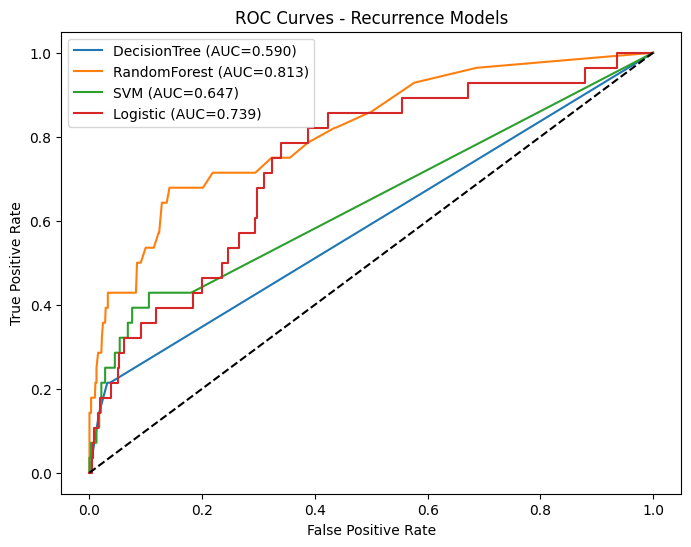

In [31]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve


models = {
    "DecisionTree": best_dt_model,
    "RandomForest": best_rf,
    "SVM": best_svm_model,
    "Logistic": log
}

plt.figure(figsize=(8,6))

for name, model in models.items():
    # Get probability scores
    try:
        proba = model.predict_proba(X_test_p)[:, 1]   # For models that support predict_proba
    except Exception:
        proba = model.decision_function(X_test_p)     # For SVM without probability=True

    # AUC Score
    auc = roc_auc_score(y_test, proba)

    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")


plt.plot([0, 1], [0, 1], 'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.title("ROC Curves - Recurrence Models")
plt.show()


# Feature importance + SHAP (RF)

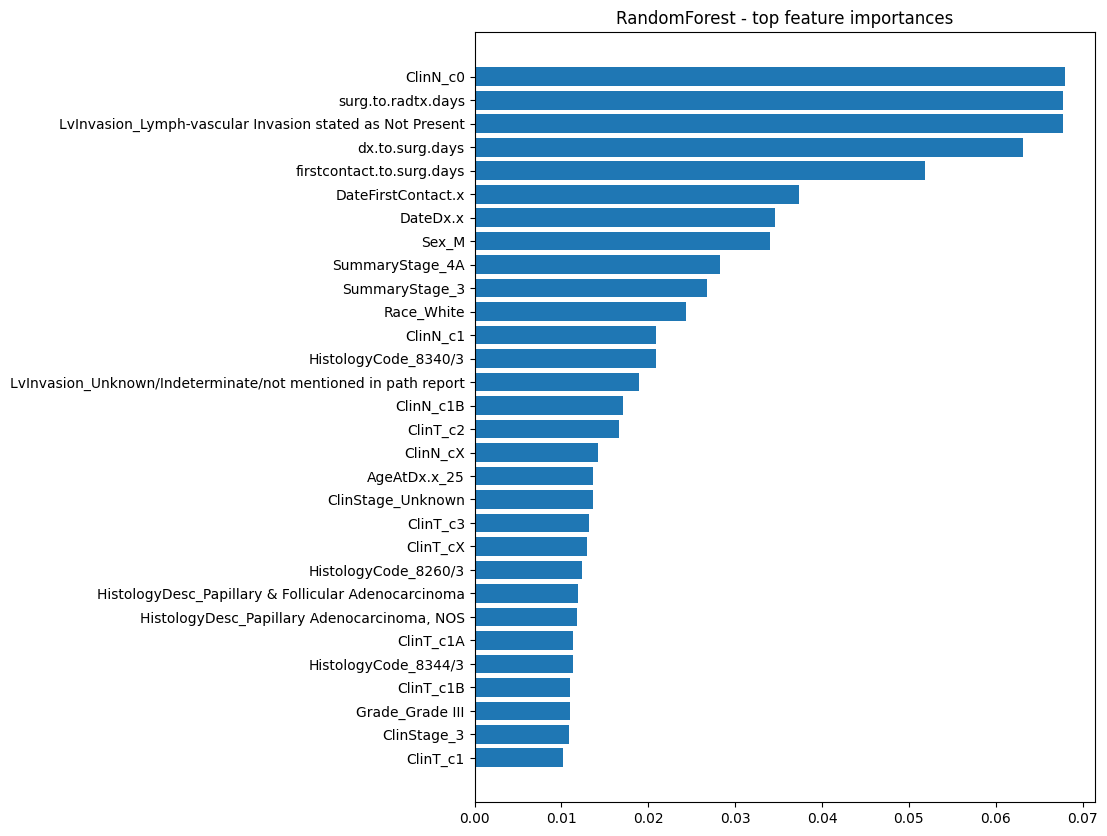

<Figure size 640x480 with 0 Axes>

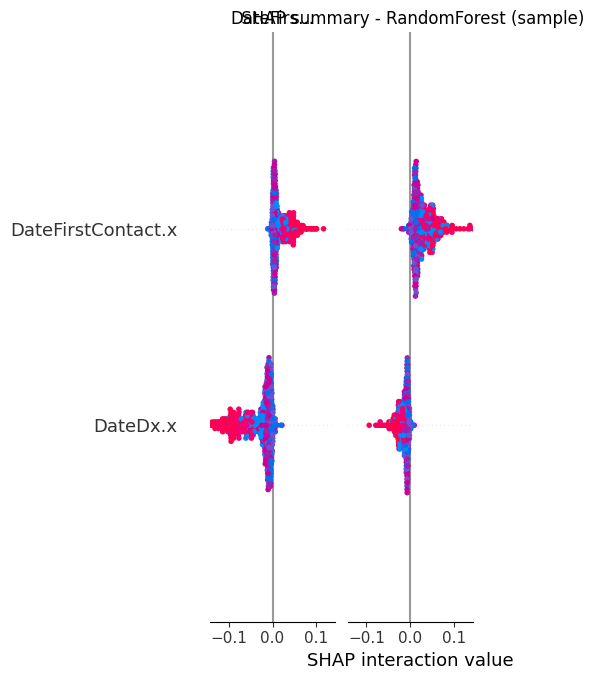

In [32]:
import matplotlib.pyplot as plt

# RF feature importance
fi = best_rf.feature_importances_
indices = np.argsort(fi)[-30:]
plt.figure(figsize=(8,10))
plt.barh(range(len(indices)), fi[indices])
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.title("RandomForest - top feature importances")
plt.show()

# SHAP for best RF (sample)
explainer = shap.TreeExplainer(best_rf)
X_shap = X_test_p if X_test_p.shape[0] < 500 else X_test_p.sample(500, random_state=42)
shap_values = explainer.shap_values(X_shap)
plt.figure()
shap.summary_plot(shap_values, X_shap, feature_names=feature_names, show=False)
plt.title(" SHAP summary - RandomForest (sample)")
plt.show()


# Save preprocessor


In [33]:
joblib.dump(preprocessor, "preprocessor_rec.joblib")


joblib.dump(best_dt_model, "best_dt_rec.joblib")
joblib.dump(best_rf, "best_rf_rec.joblib")
joblib.dump(best_svm_model, "best_svm_rec.joblib")
joblib.dump(log, "best_log_rec.joblib")

print("Saved preprocessor, DecisionTree, RandomForest, SVM, and Logistic models successfully.")


Saved preprocessor, DecisionTree, RandomForest, SVM, and Logistic models successfully.


# Plot

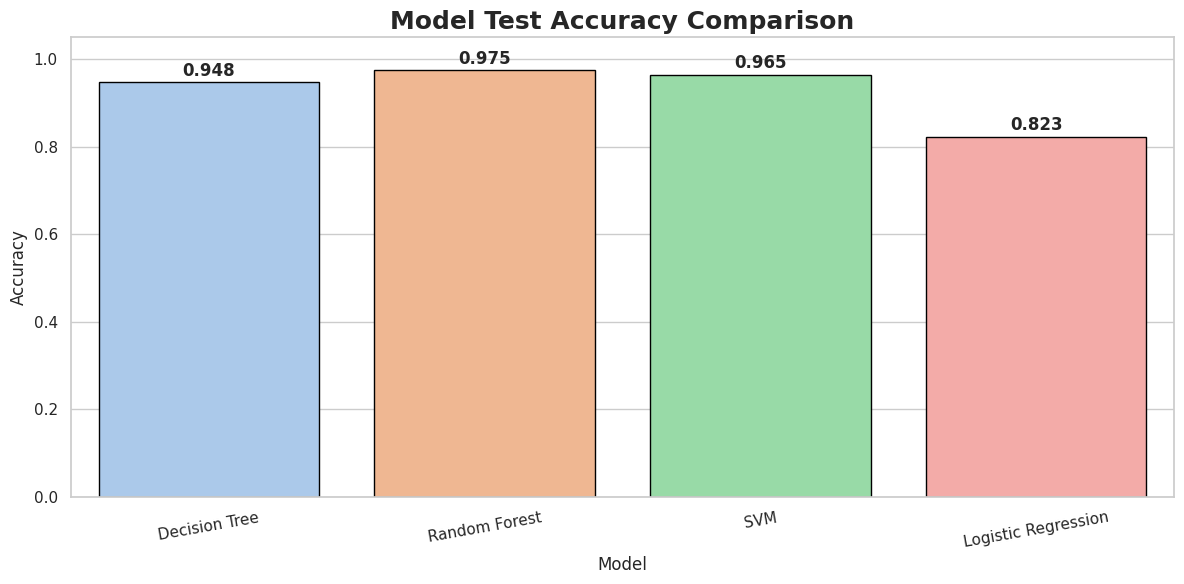

In [34]:

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

sns.set_theme(style="whitegrid")

acc_df = pd.DataFrame({
    "Model": ["Decision Tree", "Random Forest", "SVM", "Logistic Regression"],
    "Accuracy": [
        accuracy_score(y_test, dt_improved.predict(X_test_p)),
        accuracy_score(y_test, best_rf.predict(X_test_p)),
        accuracy_score(y_test, best_svm_model.predict(X_test_p)),
        accuracy_score(y_test, log.predict(X_test_p))
    ]
})

plt.figure(figsize=(12,6))
sns.barplot(data=acc_df, x="Model", y="Accuracy", palette="pastel", edgecolor="black")

for i, v in enumerate(acc_df["Accuracy"]):
    plt.text(i, v + 0.015, f"{v:.3f}", ha='center', fontsize=12, fontweight="bold")

plt.title("Model Test Accuracy Comparison", fontsize=18, fontweight="bold")
plt.ylim(0,1.05)
plt.xticks(rotation=10)
plt.tight_layout()
plt.show()


In [35]:
from sklearn import set_config
set_config(display='diagram')
preprocessor


ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['DateFirstContact.x', 'DateDx.x',
                                  'dx.to.surg.days',
                                  'firstcontact.to.surg.days',
                                  'surg.to.radtx.days']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 ['AgeAtDx.x', 'PrimarySiteCode',
                                  'PrimarySiteDesc', 'PrimarySiteCategory',
                                  'PrimarySiteSubcategory.x', 'HistologyCode',
                                  'HistologyDesc', 'Laterality', 'Grade',
                                  'LvInvasion', 'ClinT', 'ClinN', 'ClinM',
                                  'ClinStage', 'SummaryStage', 'Sex',
                                  'Race'])])

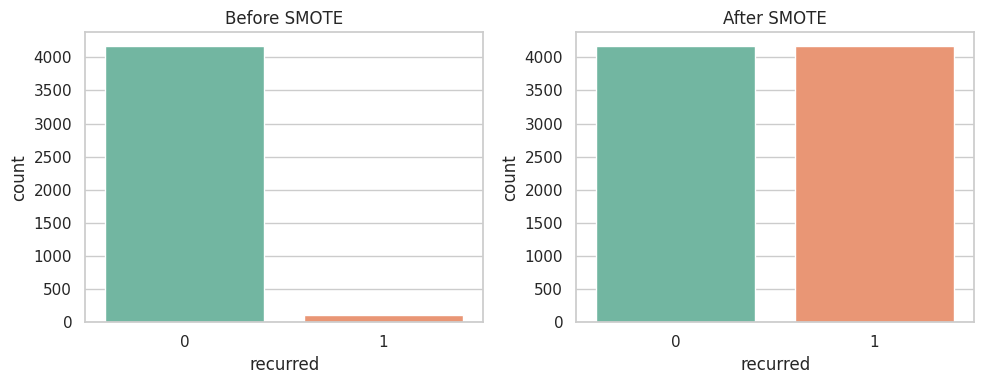

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.countplot(x=y_train, palette="Set2")
plt.title("Before SMOTE")

plt.subplot(1,2,2)
sns.countplot(x=y_train_bal, palette="Set2")
plt.title("After SMOTE")

plt.tight_layout()
plt.show()


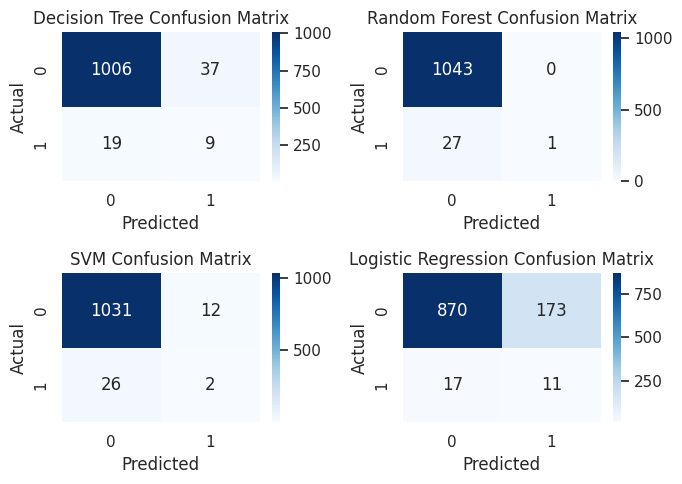

In [37]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

models = {
    "Decision Tree": dt_improved,
    "Random Forest": best_rf,
    "SVM": best_svm_model,
    "Logistic Regression": log
}

plt.figure(figsize=(7,5))
i = 1

for name, model in models.items():
    plt.subplot(2,2,i)
    cm = confusion_matrix(y_test, model.predict(X_test_p))
    sns.heatmap(cm, annot=True, cmap="Blues", fmt="d")
    plt.title(f"{name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    i += 1

plt.tight_layout()
plt.show()


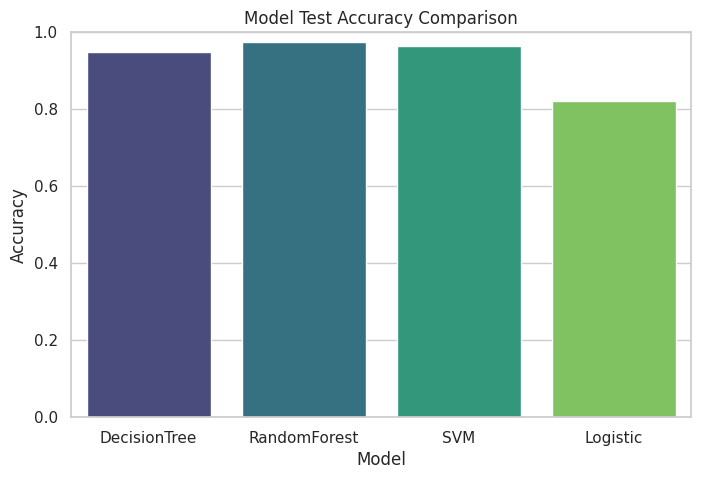

In [38]:
import seaborn as sns
import matplotlib.pyplot as plt

model_names = ["DecisionTree", "RandomForest", "SVM", "Logistic"]
test_accuracies = [
    accuracy_score(y_test, dt_improved.predict(X_test_p)),
    accuracy_score(y_test, best_rf.predict(X_test_p)),
    accuracy_score(y_test, best_svm_model.predict(X_test_p)),
    accuracy_score(y_test, log.predict(X_test_p))
]

plt.figure(figsize=(8,5))
sns.barplot(x=model_names, y=test_accuracies, palette="viridis")
plt.ylim(0, 1)
plt.title("Model Test Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xlabel("Model")
plt.show()


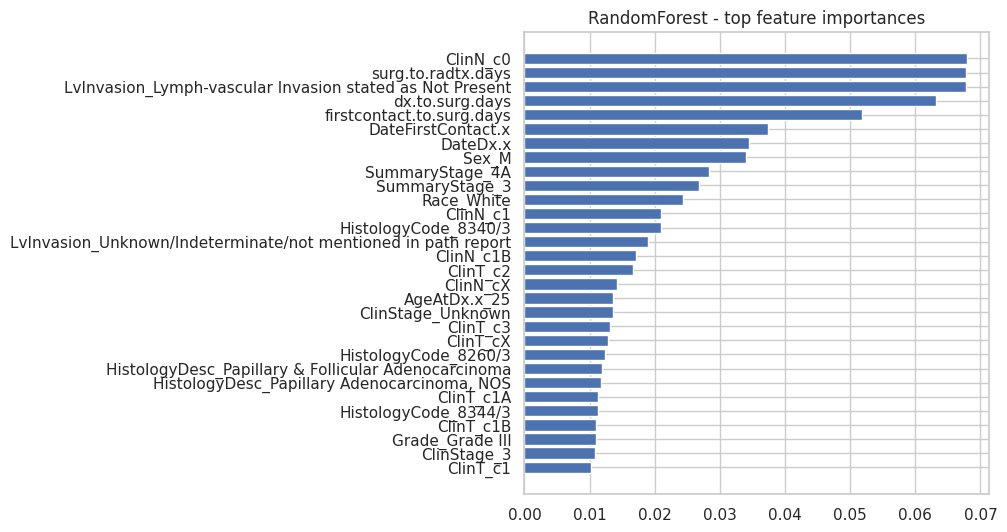

In [39]:
import matplotlib.pyplot as plt

# RF feature importance
fi = best_rf.feature_importances_
indices = np.argsort(fi)[-30:]
plt.figure(figsize=(6,6))
plt.barh(range(len(indices)), fi[indices])
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.title("RandomForest - top feature importances")
plt.show()


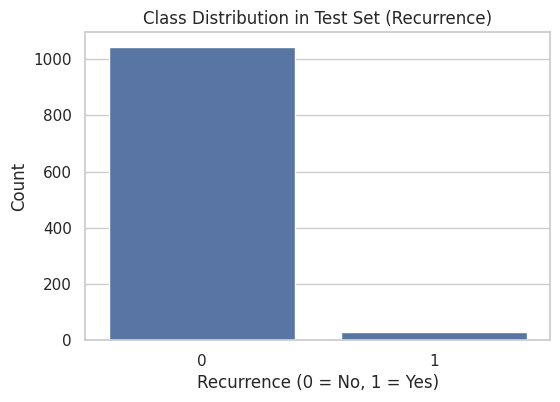

In [40]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.countplot(x=y_test)
plt.title("Class Distribution in Test Set (Recurrence)")
plt.xlabel("Recurrence (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()
